<a href="https://colab.research.google.com/github/timlin901222/2048game/blob/master/Tims_hw2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Tokenization, Word Embeddings, and Vector Algebra

## Introduction
In this assignment, we will explore the problem of getting from sequences of characters to wordtypes with different meanings. You will implement widely-used algorithms for tokenizing text and computing context-less word embeddings, and perform analysis on the results of running these algorithms.

Learning objectives:
* Understand how byte pair encoding works as a method for tokenizing character sequences, and how it differs from simpler tokenization methods like splitting on whitespace.
* Gain insights on how to compute and interpret language statistics, including Zipf's laws of word frequencies.
* Understand basics of distributional semantics, including basic implementations of word embedding algorithms.
* Learn to use vector algebra as a way of analyzing a space of word embeddings.

**Notes:**
* In your solution, complete the TODO sections. You may add code cells for the report and adjust the documented training settings. Keep function names, signatures, and output filenames unchanged.
* Items marked with a star (★) should be answered in a separate report as a text document with the corresponding item number. You will include your final report as a pdf with your submission.

* Graded functions should use their arguments, imports, other functions/classes, or literal constants; do not depend on top-level training/report variables. Use ordinary Python code cells (no shell commands or IPython magics).

**Submission:**

Submit `submission.zip` to Gradescope. Partial work is accepted: include your notebook
and any report or result files you have completed. Missing work earns no credit for
the affected questions; completed work is still graded. A complete submission contains:

```
hw2.ipynb # your completed jupyter notebook
report.pdf # your written report
results/ # outputs from jupyter notebook
├── skipgram_scores.npy
├── solve_analogy.json
├── W_en_fr.npy
├── W_en_ja.npy
└── ... (and all other generated files)
```

# Setup

**Google Colab:** save your own copy with **File → Save a copy in Drive**. In
**Runtime → Change runtime type**, select runtime version **2026.07** and a GPU
if available (CPU also works). Run the next cell. After the first installation,
follow its message to **Restart session**, then run the cell again and allow
Google Drive access. See [README.md](https://github.com/Louis0324/eecs183-283A-26fall-hw2#readme)
for setup and submission instructions.

**Local Jupyter:** follow the README installation steps, choose the **Python (hw2)**
kernel, and open the notebook from the homework directory.

The setup cell loads the corpus and defines `save_results`. JSON and NumPy
outputs go in `results/`; on Colab, this directory points to
`MyDrive/cs183-hw2/results` so completed outputs survive a runtime reset.


In [1]:
# On Colab, download the homework files and connect persistent storage.
# On a local machine, use the environment described in README.md.
import sys
if "google.colab" in sys.modules:
    import subprocess
    from pathlib import Path
    import os

    repo = Path("/content/cs183-hw2")
    if not repo.exists():
        subprocess.run([
            "git", "clone", "--depth", "1",
            "https://github.com/Louis0324/eecs183-283A-26fall-hw2.git", str(repo)
        ], check=True)
    os.chdir(repo)
    if str(repo) not in sys.path:
        sys.path.insert(0, str(repo))
    from colab_setup import setup
    setup()

import json
import os
from collections import Counter, defaultdict
from typing import List, Dict, Tuple
from itertools import islice
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tokenizers import ByteLevelBPETokenizer
from tokenizers.normalizers import Lowercase
from tqdm import tqdm

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.set_num_threads(2)

# Colab uses its assigned GPU when available. Local runs default to CPU.
device = torch.device("cuda:0" if "google.colab" in sys.modules and torch.cuda.is_available() else "cpu")
print(f"Training device: {device}")
Path("results").mkdir(exist_ok=True)

def save_results(results, filename):
    if not os.path.exists('results'):
        os.makedirs('results')
    with open(os.path.join('results', filename), "w", encoding="utf-8") as f:
        json.dump(results, f, indent=4)

# Load the corpus
with open('data/stories.txt', 'r', encoding='utf-8') as f:
    en_corpus = [line.strip() for line in f.readlines()]

print(f"Loaded {len(en_corpus)} corpus lines (some contain multiple sentences).")
print("First 5 lines:", en_corpus[:5])

Mounted at /content/drive
Setup ready. Results are saved in /content/drive/MyDrive/cs183-hw2/results.
Training device: cuda:0
Loaded 10000 corpus lines (some contain multiple sentences).
First 5 lines: ['The Happy Prince.', 'HIGH above the city, on a tall column, stood the statue of the Happy Prince.  He was gilded all over with thin leaves of fine gold, for eyes he had two bright sapphires, and a large red ruby glowed on his sword-hilt.', 'He was very much admired indeed.  “He is as beautiful as a weathercock,” remarked one of the Town Councillors who wished to gain a reputation for having artistic tastes; “only not quite so useful,” he added, fearing lest people should think him unpractical, which he really was not.', '“Why can’t you be like the Happy Prince?” asked a sensible mother of her little boy who was crying for the moon.  “The Happy Prince never dreams of crying for anything.”', '“I am glad there is some one in the world who is quite happy,” muttered a disappointed man as he

## Part 1: Tokenization (25 points)

In this part, you will implement two standard methods for tokenization to convert a sequence of characters into a sequence of tokens.

### Part 1.0: Setup
**Implement:** A helper function that, given a sequence of tokenized sentences, returns a dictionary pairing word types with their counts. Count every occurrence, including repeated tokens within a sentence. For example, `[["a", "b"], ["a"]]` gives `{"a": 2, "b": 1}`; an empty input gives `{}`.

In [ ]:
def count_word_types(tokenized_sentences: List[List[str]]) -> Dict[str, int]:
    """
    Given a list of tokenized sentences, return a dictionary mapping each word type to its frequency.
    """
    token_dict = defaultdict(int)
    for sentence in tokenized_sentences:
        for token in sentence:
            token_dict[token] += 1
    return dict(token_dict)

### Part 1.1: Simple tokenization (10 points)
**Implement:** A function that splits a given input string by whitespace into sequences of tokens.

In [ ]:
def simple_tokenize(text: str) -> List[str]:
    return text.split()


**Report:**

First compute `simple_sentences = [simple_tokenize(text) for text in en_corpus]`,
then `word_counts_output = count_word_types(simple_sentences)`.

★ 1.1.1 What are the 10 most frequent wordtypes in this frequency dictionary?

★ 1.1.2 What are two limitations you observe in this simple tokenization method? Include examples that motivate these limitations.

In [ ]:
simple_sentences = [simple_tokenize(text) for text in en_corpus]
word_counts_output = count_word_types(simple_sentences)
print(sorted(word_counts_output.items(), key=lambda x: x[1], reverse=True)[:10])

[('the', 34392), ('and', 24581), ('to', 15159), ('a', 10956), ('he', 9618), ('of', 9241), ('was', 7858), ('in', 6552), ('his', 5785), ('that', 5705)]


1.1.1 Answer: [('the', 34392), ('and', 24581), ('to', 15159), ('a', 10956), ('he', 9618), ('of', 9241), ('was', 7858), ('in', 6552), ('his', 5785), ('that', 5705)]

1.1.2 Answer: (1) Trailing punctuation causes the same word to be parsed into different entries. "Prince.", "Prince,", and "Prince?" are treated as different keys in the frequency dictionary even though they're the same word. (2) Case sensitivity treats the same word as different types. "The" and "the" count as separate keys even though they refer to the same word.

### Part 1.2: Byte pair encoding (15 points)
**Implement:** Complete the character-based BPE class below. This teaching version starts with Unicode characters; Part 2 uses a library implementation that starts with bytes.

1. `get_stats(word_freqs)` counts adjacent symbol pairs, weighted by word frequency. Keys in `word_freqs` are space-separated symbols: `{"a a a b": 2}` has pair counts `('a', 'a'): 4` and `('a', 'b'): 2`.
2. `merge(pair, word_freqs)` returns a new frequency dictionary, replacing non-overlapping occurrences from left to right. For example, merging `('a', 'a')` changes `"a a a b"` to `"aa a b"`. Match whole symbols, not substrings.
3. `train` resets previous state and merges the most frequent pair until `len(self.vocab) >= vocab_size` or no pairs remain. Break frequency ties by choosing the lexicographically smallest pair. Keep `self.vocab` as `{integer_id: symbol}` and `self.merges` as `{(left, right): merged_symbol}` in learning order. Retain existing vocabulary entries; add a merged symbol only if it is new. Reject a requested size smaller than the initial character vocabulary.
4. `tokenize` splits on whitespace and applies the learned merges to each word in learning order. Insert the literal token `" "` between words so their boundaries survive. This separator is never merged and does not count toward `vocab_size`. Unseen characters remain character tokens.
5. `decode` joins the tokens. The round trip normalizes whitespace: `decode(tokenize(text)) == " ".join(text.split())`. For example, a tokenizer with no merges maps `"ab  c"` to `["a", "b", " ", "c"]` and decodes to `"ab c"`. Empty text gives `[]` and decodes to `""`.

In [ ]:
class BPE():
    def __init__(self):
        self.merges = {}
        self.vocab = {}

    def get_stats(self, word_freqs):
        pair_frequency = defaultdict(int)
        for word, freq in word_freqs.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pair_frequency[(symbols[i], symbols[i + 1])] += freq
        return pair_frequency

    def merge(self, pair, word_freqs):
        left, right = pair
        merged_symbol = left + right
        new_word_freqs = {}
        for word, freq in word_freqs.items():
            symbols = word.split(' ')
            new_symbols = []
            i = 0
            while i < len(symbols):
                if i < len(symbols) - 1 and symbols[i] == left and symbols[i + 1] == right:
                    new_symbols.append(merged_symbol)
                    i += 2
                else:
                    new_symbols.append(symbols[i])
                    i += 1
            new_word = ' '.join(new_symbols)
            new_word_freqs[new_word] = new_word_freqs.get(new_word, 0) + freq
        return new_word_freqs

    def train(self, corpus: list[str], vocab_size: int):
        self.merges = {}
        self.vocab = {}
        initial_vocab = set()
        word_freqs = defaultdict(int)
        for text in corpus:
            words = text.strip().split()
            for word in words:
                processed_word = ' '.join(list(word))
                word_freqs[processed_word] += 1
                initial_vocab.update(list(word))
        self.vocab = {i: char for i, char in enumerate(sorted(list(initial_vocab)))}
        if vocab_size < len(self.vocab):
            raise ValueError("vocab_size must include all initial characters")
        vocab_symbols = set(self.vocab.values())
        while len(self.vocab) < vocab_size:
            pair_frequency = self.get_stats(word_freqs)
            if not pair_frequency:
                break
            most_frequent_pair = min(pair_frequency, key=lambda x: (-pair_frequency[x], x))
            merged_symbol = ''.join(most_frequent_pair)
            self.merges[most_frequent_pair] = merged_symbol
            word_freqs = self.merge(most_frequent_pair, word_freqs)
            if merged_symbol not in vocab_symbols:
                self.vocab[len(self.vocab)] = merged_symbol
                vocab_symbols.add(merged_symbol)

    def tokenize(self, text: str) -> list[str]:
        words = text.split()
        tokens = []
        for i, word in enumerate(words):
            current_word = ' '.join(list(word))
            for pair in self.merges:
                merged = self.merge(pair, {current_word: 1})
                [current_word] = merged
            tokens.extend(current_word.split(' '))
            if i < len(words) - 1:
                tokens.append(' ')
        return tokens

    def decode(self, tokens: list[str]) -> str:
        return ''.join(tokens)

#### 💾 Save your results for `BPE`

In [ ]:
bpe_tokenizer = BPE()
bpe_tokenizer.train(en_corpus, vocab_size=500)

# Save the learned merges and vocabulary
save_results({str(k): v for k, v in bpe_tokenizer.merges.items()}, 'bpe_merges.json')
save_results(bpe_tokenizer.vocab, 'bpe_vocab.json')
print("Saved results for BPE merges and vocabulary.")

Saved results for BPE merges and vocabulary.


**Report:**

★ 1.2.1 What are the 10 most frequent token types from your BPE tokenizer? Exclude the literal `" "` boundary token from frequency counts and plots.

★ 1.2.2 Generate a plot showing the Zipfian distribution of wordtypes (i.e., a log-log plot of frequency vs. rank). Compare the distributions from simple whitespace tokenization and BPE, using the full corpus for both. Include the plots and your comparison in the report, make sure your plot is clearly labeled.

★ 1.2.3 Why might these distributions look different from one another?

1.2.1 Answer: 'e': 291861, 't': 208957, 'a': 182766, 'h': 176648, 'o': 166640, 'n': 150590, 'i': 133220, 's': 126879, 'r': 119415, 'd': 113277

1.2.2 Answer: The two schemes produce noticeably different curves. Whitespace tokenization spans a very wide rank range, with 30,000+ wordytpes, and declines smoothly and gradually across nearly the whole range, ending in a long flat tail of thousands of wordtypes that occur only once or twice. BPE spans only about 80–90 distinct token types before reaching frequency 1: it starts much higher (its most frequent token occurs roughly 8–10x more often than whitespace's most frequent word), stays relatively flat for the first ~10–20 ranks, then drops off in a near-vertical cliff rather than a gradual decline. The curves cross around rank 30–40; below that BPE tokens are consistently more frequent, above it whitespace continues for thousands of additional ranks while BPE has nothing left.

1.2.3 Answer: Whitespace tokenization has an effectively unbounded vocabulary, which produces a huge number of wordtypes that each appear only a handful of times, hence the long smooth tail. BPE is capped at a fixed vocabulary size and its units are subword pieces that get reused across many words, so a small number of symbols absorb a disproportionate share of all occurrences, producing the tall flat head.

In [ ]:
f# TODO: Use this space to generate your Zipfian plot.
# Tip: tokenize each distinct whitespace word once and weight its tokens by the word count.
bpe_sentences = [bpe_tokenizer.tokenize(text) for text in en_corpus]
bpe_token_counts = count_word_types(bpe_sentences)

# Exclude the literal " " boundary token from frequency counts
bpe_token_counts_no_boundary = {tok: cnt for tok, cnt in bpe_token_counts.items() if tok != ' '}

top10_bpe = sorted(bpe_token_counts_no_boundary.items(), key=lambda kv: (-kv[1], kv[0]))[:10]
for token, count in top10_bpe:
    print(f"{token!r}: {count}")

'the': 35285
',': 30195
'and': 26701
's': 20350
'a': 17928
'to': 17864
'.': 15017
't': 14150
'he': 12738
'in': 11956


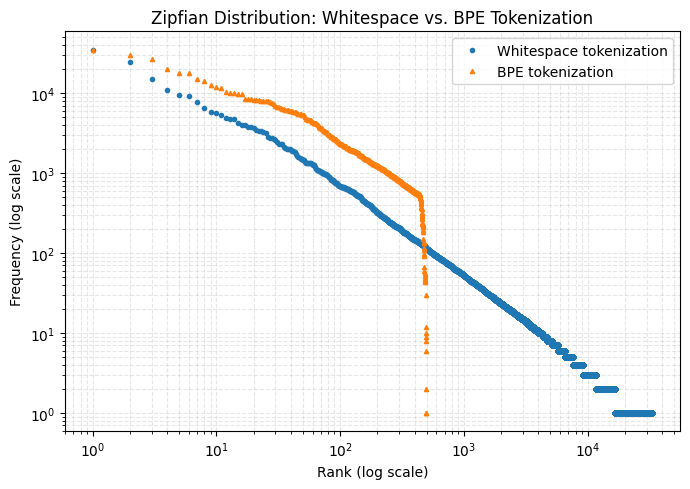

In [ ]:
import matplotlib.pyplot as plt

def zipf_ranks_freqs(counts: dict):
    freqs = sorted(counts.values(), reverse=True)
    ranks = range(1, len(freqs) + 1)
    return ranks, freqs

simple_ranks, simple_freqs = zipf_ranks_freqs(word_counts_output)              # from Part 1.1
bpe_ranks, bpe_freqs = zipf_ranks_freqs(bpe_token_counts_no_boundary)          # boundary token excluded

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(simple_ranks, simple_freqs, marker='o', markersize=3, linestyle='none',
          color='#1f77b4', label='Whitespace tokenization')
ax.loglog(bpe_ranks, bpe_freqs, marker='^', markersize=3, linestyle='none',
          color='#ff7f0e', label='BPE tokenization')

ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Frequency (log scale)')
ax.set_title('Zipfian Distribution: Whitespace vs. BPE Tokenization')
ax.legend()
ax.grid(True, which='both', linestyle='--', alpha=0.3)
fig.tight_layout()
fig.savefig('results/zipf_plot.png', dpi=150)
plt.show()

## Part 2: Word embeddings (25 points)

In this part, you will implement the Skip-Gram model to compute word embeddings for the words in your corpus.

### Part 2.0: Setup
For the remainder of Part 2, use `ByteLevelBPETokenizer` from the pinned `tokenizers` library. Train it on the full corpus with the settings below; the supplied evaluation arrays use this vocabulary. Save its configuration with your results.

Treat each corpus line as one sequence and never create contexts across line boundaries. The variable `en_tokenized` contains integer token IDs, not strings. For the context comparison in the report, use only `context_corpus = en_tokenized[:100]` for all three settings. This limits the quadratic cost of bag-of-words pairs. Skip-Gram training still uses the full corpus with a local window.

In [ ]:
def get_tokenizer(data_path: str, vocab_size=10000):
    tokenizer = ByteLevelBPETokenizer()
    tokenizer.normalizer = Lowercase()

    tokenizer.train(files=data_path, vocab_size=vocab_size, min_frequency=2)

    return tokenizer

en_tokenizer = get_tokenizer("data/stories.txt")
en_tokenized = [en_tokenizer.encode(s).ids for s in en_corpus]
context_corpus = en_tokenized[:100]
en_tokenizer.save("results/en_tokenizer.json")

### Part 2.1: Experiment with different contexts (5 points)
**Implement:** Two functions returning lists of `(target_id, context_id)` pairs.

**a) Bag-of-words context:** For each token position, pair its token with every other position in the same sequence. A sequence of length $m$ contributes $m(m-1)$ pairs. Exclude the target position, not every occurrence of the same token ID: `[[1, 1, 2]]` must contain two `(1, 1)` pairs.

**b) Neighboring-token context:** Pair each target with the tokens at most `window_size` positions to either side. Clip the window at sequence boundaries; do not add BOS/EOS tokens or position labels. For `[[1, 2, 3]]` and a window of 1, return `[(1, 2), (2, 1), (2, 3), (3, 2)]`.

For both functions, visit sequences, target positions, and context positions in their original order, preserving duplicate pairs. Empty and one-token sequences contribute no pairs. A zero window gives no pairs; reject a negative window with `ValueError`.

In [ ]:
def get_bow_context(tokenized_sentences: List[List[int]]) -> List[Tuple[int, int]]:
    """
    Creates positive (target, context) examples where context is any other word in the sentence.
    """
    # TODO: Implement this function
    result = []
    for sentence in tokenized_sentences:
        if len(sentence) <= 1:
            continue
        for i, target in enumerate(sentence):
            for context in sentence[:i] + sentence[i+1:]:
                result.append((target, context))
    return result


def get_neighbor_context(tokenized_sentences: List[List[int]], window_size: int) -> List[Tuple[int, int]]:
    """
    Creates positive (target, context) examples from tokens within a given window size.
    """
    # TODO: Implement this function
    if window_size < 0:
        raise ValueError("Window size must be non-negative")
    result = []
    for sentence in tokenized_sentences:
        if len(sentence) <= 1:
            continue
        for i, target in enumerate(sentence):
            for j in range(max(0, i - window_size), min(i + window_size + 1, len(sentence))):
                if j == i:
                    continue
                result.append((target, sentence[j]))
    return result

#### 💾 Save your results for `get_neighbor_context`

In [ ]:
neighbor_pairs = get_neighbor_context(context_corpus, window_size=2)
save_results(neighbor_pairs[:10000], 'neighbor_context.json')
print("Saved results for get_neighbor_context.")

Saved results for get_neighbor_context.



### Part 2.2: Negative sampling (5 points)
To train the Skip-Gram model efficiently, we use negative sampling. First, we model the probability distribution over contexts.

**Implement:** A function that computes a distribution over the contexts $\mathcal{C}$ given a dataset of word-context pairs $\mathcal{D}$. Use the empirical context frequency divided by the total number of pairs, with no smoothing or exponent. Include a zero probability for vocabulary IDs that never appear as contexts. Reject an empty pair list with `ValueError`.

In [ ]:
def get_context_distribution(pairs: List[Tuple[int, int]], vocab_size: int) -> List[float]:
    """
    Computes the probability distribution over contexts P(c).

    Args:
        pairs: A list of (token, context) pairs.
        vocab_size: The size of the vocabulary.

    Returns:
        A list of probabilities for each context token, ordered by token index.
    """
    # TODO: Implement this function

    if len(pairs) == 0:
        raise ValueError("pairs must not be empty")
    context_counts = [0] * vocab_size
    for _, context in pairs:
        context_counts[context] += 1
    total = len(pairs)
    return [count / total for count in context_counts]



**Implement:** A function for sampling negative pairs of tokens and contexts given the prior over contexts $\mathcal{C}$. Draw independently with replacement, returning a `torch.long` tensor of shape `(batch_size, num_samples)` on the distribution's device. Do not reject a draw just because it matches a positive context; accidental matches are allowed. For example, `[0., 1., 0.]` always samples ID 1.

In [ ]:

def sample_negative_contexts(context_distribution: torch.Tensor, num_samples: int, batch_size=1) -> torch.Tensor:
    """
    Samples negative contexts based on the context distribution.
    """
    # TODO: Implement this function

    probs = context_distribution.unsqueeze(0).expand(batch_size, -1)
    return torch.multinomial(probs, num_samples, replacement=True).long()

**Report:**

★ 2.2.1 For each of the following context settings, list the highest-probability *negative* sample according to the priors you computed on `context_corpus`. Decode the most likely ID and report its probability; do not generate all bag-of-words pairs for the full corpus:
- Context as a bag of words.
- Context as neighboring tokens, $N=1$.
- Context as neighboring tokens, $N=2$.

In [ ]:
vocab_size = len(en_tokenizer.get_vocab())

context_settings = {
    "Bag of words": get_bow_context(context_corpus),
    "Neighboring tokens (N=1)": get_neighbor_context(context_corpus, window_size=1),
    "Neighboring tokens (N=2)": get_neighbor_context(context_corpus, window_size=2),
}

for name, pairs in context_settings.items():
    distribution = get_context_distribution(pairs, vocab_size)
    best_id = int(np.argmax(distribution))
    best_prob = distribution[best_id]
    decoded = en_tokenizer.decode([best_id])
    print(f"{name}: most likely negative sample = {decoded!r} (id={best_id}), P(c) = {best_prob:.4f}")

Bag of words: most likely negative sample = ' the' (id=259), P(c) = 0.0657
Neighboring tokens (N=1): most likely negative sample = ' the' (id=259), P(c) = 0.0654
Neighboring tokens (N=2): most likely negative sample = ' the' (id=259), P(c) = 0.0655


### Part 2.3: Train the Skip-Gram model and analyze embeddings (15 points)

Now, we'll define our Skip-Gram model and train it on our corpus.

**Implement:** A Skip-Gram model in PyTorch. The model should consist of two embedding layers: one for the target words and one for the context words, named `target_embeddings` and `context_embeddings`.

`forward` returns dot-product **logits**, without a sigmoid. Targets have shape `(B,)`; contexts may have shape `(B,)` for one context per target or `(B, K)` for several. Return shape `(B,)` or `(B, K)`, respectively. Use target embeddings for the cosine-similarity exercise. Initialize the weights with small values (for example, uniformly in `[-0.5 / embedding_dim, 0.5 / embedding_dim]`) so initial logits stay close to zero.

In [ ]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super(SkipGramModel, self).__init__()
        self.target_embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embedding_dim)
        init_range = 0.5 / embedding_dim
        nn.init.uniform_(self.target_embeddings.weight, -init_range, init_range)
        nn.init.uniform_(self.context_embeddings.weight, -init_range, init_range)

    def forward(self, target, context):
        # TODO: Implement the forward pass
        target_embeddings = self.target_embeddings(target)
        context_embeddings = self.context_embeddings(context)
        if context.dim() > 1:
            target_embeddings = target_embeddings.unsqueeze(1)
        logits = torch.sum(target_embeddings * context_embeddings, dim=-1)
        return logits

**Implement:** Complete the training loop. Use the full corpus and a clipped context window of five.

For each batch, draw **10 negative contexts per positive pair** from the empirical context distribution. Place the positive context in column 0 followed by the ten negatives. Use labels 1 for the positive column and 0 for the negative columns, and average `BCEWithLogitsLoss` over all entries. Clear gradients, backpropagate, and update the optimizer each batch.

The supplied dataset stores pairs in compact integer arrays, preparing one corpus line at a time. The defaults are 10 epochs, a batch size of 1024, and learning rate 0.001; CPU is sufficient. You may adjust `batch_size`, `num_epochs`, and `device` while debugging. Start with one epoch on a small corpus, then train on the full corpus for the saved evaluation. Keep the tokenizer settings, embedding dimension, context window, and number of negatives unchanged. Inspect epoch losses to check learning.

In [ ]:
class SkipGramDataset(Dataset):
    def __init__(self, tokenized_sentences, window_size=5):
        chunks = []
        for sentence in tokenized_sentences:
            pairs = get_neighbor_context([sentence], window_size)
            if pairs:
                chunks.append(np.asarray(pairs, dtype=np.int32))
        self.pairs = np.concatenate(chunks) if chunks else np.empty((0, 2), dtype=np.int32)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        return self.pairs[idx].astype(np.int64)


def train_skipgram(corpus, tokenizer, num_epochs=10, batch_size=1024, device="cpu"):
    device = torch.device(device)
    embedding_dim = 128
    vocab_size = len(tokenizer.get_vocab())
    model = SkipGramModel(vocab_size, embedding_dim).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    dataset = SkipGramDataset((tokenizer.encode(s).ids for s in corpus), window_size=5)
    if len(dataset) == 0:
        raise ValueError("Training requires at least one target/context pair")
    context_distribution = torch.tensor(
        get_context_distribution(dataset.pairs, vocab_size), dtype=torch.float32, device=device
    )
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    num_negatives = 10

    # TODO: Implement the training loop and print the average loss each epoch.
    # Each batch is an integer tensor of shape (B, 2): target IDs, context IDs.

    for epoch in range(num_epochs):
        total_loss = 0
        for batch in dataloader:
            batch = batch.to(device)
            target, context = batch[:, 0], batch[:, 1]
            B = target.shape[0]

            negatives = sample_negative_contexts(context_distribution, num_negatives, batch_size=B)
            positive_contexts_col = context.unsqueeze(1)
            all_contexts = torch.cat([positive_contexts_col, negatives], dim=1)

            pos_labels = torch.ones(B, 1, dtype=torch.float32, device=device)
            neg_labels = torch.zeros(B, num_negatives, dtype=torch.float32, device=device)
            labels = torch.cat([pos_labels, neg_labels], dim=1)

            optimizer.zero_grad()
            logits = model(target, all_contexts)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch + 1}/{num_epochs}, Average Loss: {total_loss / len(dataloader):.4f}")

    return model

#### 💾 Save your model outputs

In [ ]:
model = train_skipgram(en_corpus, en_tokenizer, num_epochs=10, batch_size=1024, device=device)

test_center_word = torch.from_numpy(np.load("data/center_word.npy")).long()
test_context_words = torch.from_numpy(np.load("data/context_words.npy")).long()

# Evaluate in small batches instead of allocating all 65,536 examples on the device.
model.eval()
model_device = next(model.parameters()).device
test_scores = []
with torch.no_grad():
    for start in range(0, len(test_center_word), 1024):
        scores = model(
            test_center_word[start:start + 1024].to(model_device),
            test_context_words[start:start + 1024].to(model_device),
        )
        test_scores.append(scores.cpu())
test_scores = torch.cat(test_scores).numpy()
assert test_scores.shape == test_context_words.shape
assert np.isfinite(test_scores).all()
np.save("results/skipgram_scores.npy", test_scores)

Epoch 1/10, Average Loss: 0.3069
Epoch 2/10, Average Loss: 0.2927
Epoch 3/10, Average Loss: 0.2893
Epoch 4/10, Average Loss: 0.2869
Epoch 5/10, Average Loss: 0.2850
Epoch 6/10, Average Loss: 0.2835
Epoch 7/10, Average Loss: 0.2822
Epoch 8/10, Average Loss: 0.2811
Epoch 9/10, Average Loss: 0.2802
Epoch 10/10, Average Loss: 0.2794


**Implement:** A function that, given a trained Skip-Gram model and a target wordtype, returns the cosine similarity of that wordtype's embedding with the embedding of every other wordtype in the vocabulary. Here `target_word` must be an **exact tokenizer vocabulary entry** (use `tokenizer.get_vocab()` to inspect entries; `Ġ` marks a leading space). Look up its ID directly rather than encoding and taking the first subword. Raise `ValueError` if the entry is missing. Return all other raw token strings, sorted by descending similarity; break ties by token ID. Define cosine similarity with a zero vector as 0.

In [ ]:
def get_cosine_similarity(model: SkipGramModel, tokenizer: ByteLevelBPETokenizer, target_word: str) -> List[Tuple[str, float]]:
    """
    Given a trained model and a target word, returns a list of (word, similarity_score)
    for all words in the vocabulary (excluding the target word), sorted by similarity score.
    """
    # TODO: Implement this function
    vocab = tokenizer.get_vocab()
    if target_word not in vocab:
        raise ValueError(f"{target_word!r} is not in the tokenizer vocabulary")
    target_id = vocab[target_word]
    embeddings = model.target_embeddings.weight.detach().cpu().numpy()
    norms = np.linalg.norm(embeddings, axis=1)
    target_vec = embeddings[target_id]
    target_norm = norms[target_id]
    dots = embeddings @ target_vec
    denom = norms * target_norm
    similarities = np.zeros(len(embeddings), dtype=np.float64)
    valid = denom > 0
    similarities[valid] = dots[valid] / denom[valid]
    id_to_token = {idx: tok for tok, idx in vocab.items()}
    order = sorted(
        (idx for idx in range(len(embeddings)) if idx != target_id),
        key=lambda idx: (-similarities[idx], idx),
    )
    return [(id_to_token[idx], float(similarities[idx])) for idx in order]

**Report:**

★ 2.3.1 Use `get_cosine_similarity` to explore similar wordtypes for different English words. Give three examples of pairs of similar wordtypes that make sense, and three that don't. What are possible reasons for a high similarity score between two seemingly unrelated words?

In [ ]:
candidate_words = ["prince", "king", "boy", "heart", "little", "gold"]
for word in candidate_words:
    try:
        similarities = get_cosine_similarity(model, en_tokenizer, word)
        print(f"\nTop 5 most similar tokens to {word!r}:")
        for token, score in similarities[:5]:
            print(f"  {token!r}: {score:.3f}")
    except ValueError as e:
        print(f"\n{word!r}: {e}")


Top 5 most similar tokens to 'prince':
  'Ġahmed': 0.580
  'Ġprince': 0.554
  'Ġhoussain': 0.551
  'Ġali': 0.549
  'cinderella': 0.526

Top 5 most similar tokens to 'king':
  'Ġpotat': 0.559
  'Ġsympath': 0.544
  'Ġtiger': 0.474
  'chief': 0.468
  'Ġfun': 0.451

Top 5 most similar tokens to 'boy':
  'fox': 0.532
  'merchant': 0.530
  'Ġpeb': 0.504
  'pi': 0.496
  'girl': 0.492

Top 5 most similar tokens to 'heart':
  'Ġmeh': 0.560
  'Ġhaw': 0.524
  'ki': 0.487
  'aker': 0.481
  'fig': 0.480

Top 5 most similar tokens to 'little':
  'bleat': 0.550
  'cap': 0.504
  'Ġbleat': 0.498
  'hun': 0.493
  'Ġes': 0.472

'gold': 'gold' is not in the tokenizer vocabulary


**2.3.1 Answer:**

**Pairs that make sense:**
1. `prince` / `Ġprince` (0.554): same word, and the leading-space version shows up in the same contexts.
2. `prince` / `Ġahmed` (0.580): Ahmed is one of the princes in the Arabian Nights stories, so the two words fill the same role.
3. `boy` / `girl` (0.492): both are young human characters that show up in parallel contexts ("the little boy/girl").

**Pairs that don't make sense:**
1. `king` / `Ġpotat` (0.559): "potat" is a subword fragment of "potato."
2. `heart` / `Ġmeh` (0.560): "meh" is a BPE fragment with no meaning of its own.
3. `little` / `bleat` (0.550): a size adjective and a sheep sound aren't related.

**Why unrelated words can score high:**
- **BPE fragments:** pieces like "potat" only appear inside a few words, so their embeddings end up in arbitrary places.
- **Shared position:** tokens that always appear in the same syntactic slot look similar even when their meanings differ.
- **Co-occurrence:** skip-gram rewards words that appear near each other, so words from the same fable score high whether or not their meanings are related.


## Part 3: Vector algebra (25 points)
Use the pinned spaCy models installed with `pip install -r requirements-models.txt` (see README.md). All three have 300-dimensional vectors. The helpers below use vector-backed vocabulary entries, not whichever lexemes happen to have been visited by the NLP pipeline.

### Part 3.0: Setup

In [ ]:
import spacy

nlp_en = spacy.load("en_core_web_md")
nlp_fr = spacy.load("fr_core_news_md")
nlp_ja = spacy.load("ja_core_news_md")


def nearest_vector_words(nlp, vector, n=1, exclude=()):
    """Return up to n (word, cosine) matches from finite, nonzero vector rows."""
    vector = np.asarray(vector, dtype=np.float64)
    norm = np.linalg.norm(vector)
    if not np.isfinite(norm) or norm == 0:
        raise ValueError("The query must have a finite, nonzero vector")
    data = nlp.vocab.vectors.data
    norms = np.linalg.norm(data, axis=1)
    valid = np.isfinite(data).all(axis=1) & (norms > 0)
    similarities = np.full(len(data), -np.inf)
    similarities[valid] = (data[valid] @ (vector / norm)) / norms[valid]
    # Use the first stored key for each row, not an arbitrary pruned alias.
    excluded = {word.casefold() for word in exclude}
    row_words, excluded_rows = {}, set()
    for key, row in nlp.vocab.vectors.key2row.items():
        word = nlp.vocab.strings[key]
        if word.casefold() in excluded:
            excluded_rows.add(row)
        if valid[row]:
            row_words.setdefault(row, word)
    # Exclude input rows as well: an alias must not reintroduce an input vector.
    rows = sorted((row for row in row_words if row not in excluded_rows),
                  key=lambda row: (-similarities[row], row_words[row]))
    return [(row_words[row], float(similarities[row])) for row in rows[:n]]

### Part 3.1: Word analogy (10 points)

**Implement:** A function that, given two wordtypes representing a target analogy (e.g., *cat* and *kitten*) and an input wordtype to evaluate in that analogy (e.g., *dog*), returns the wordtype that (according to the learned embeddings) best fits as the analogy. Use cosine similarity to `vec(b) - vec(a) + vec(c)`. Exclude all three input words (case-insensitively) and their shared vector rows, reject missing/zero input vectors with `ValueError`, and return one best word as a string. The optional `n` controls how many candidates the supplied `nearest_vector_words` helper retrieves; it does not change the return type. You may call that helper. Analogy predictions need not match the illustrative expected words exactly; report both successes and failures.

In [ ]:
def solve_analogy(model, a: str, b: str, c: str, n=5) -> str:
    """
    Solves the analogy 'a is to b as c is to ?'.
    Returns the word from the vocabulary whose embedding is closest to vec(b) - vec(a) + vec(c).
    """
    nlp = model  # the spaCy Language object

    def get_vector(word):
        lex = nlp.vocab[word]
        vec = lex.vector
        norm = np.linalg.norm(vec)
        if not lex.has_vector or not np.isfinite(norm) or norm == 0:
            raise ValueError(f"No usable vector for {word!r}")
        return vec

    vec_a, vec_b, vec_c = get_vector(a), get_vector(b), get_vector(c)
    query = vec_b - vec_a + vec_c

    # exclude all three input words (case-insensitive) so the answer can't just echo the question
    matches = nearest_vector_words(nlp, query, n=n, exclude=(a, b, c))
    if not matches:
        raise ValueError("No usable candidate vectors")
    return matches[0][0]

#### 💾 Save your results for `solve_analogy`

In [ ]:
test_analogies = [
    ("king", "queen", "man", "woman"),
    ("paris", "france", "berlin", "germany"),
    ("car", "driver", "train", "conductor"),
    ("good", "better", "bad", "worse"),
    ("big", "bigger", "small", "smaller"),
    ("dog", "puppy", "cat", "kitty"),
]


analogy_results = []
for a, b, c, expected in test_analogies:
    result = solve_analogy(nlp_en, a, b, c)
    analogy_results.append(result)
    print(f"{a}:{b}::{c}:? -> {result} (expected: {expected})")

save_results(analogy_results, 'solve_analogy.json')

king:queen::man:? -> lady (expected: woman)
paris:france::berlin:? -> Germany (expected: germany)
car:driver::train:? -> trains (expected: conductor)
good:better::bad:? -> worse (expected: worse)
big:bigger::small:? -> smaller (expected: smaller)
dog:puppy::cat:? -> kitty (expected: kitty)


**Report:**

★ 3.1.1 Find three analogies in English that the model is able to solve correctly, and three analogies in English where the model gives a wrong answer.

**3.1.1 Answer:**

**Solved correctly:**
1. `good : better :: bad : ?` → **worse**
2. `big : bigger :: small : ?` → **smaller**
3. `dog : puppy :: cat : ?` → **kitty**

**Solved incorrectly:**
1. `king : queen :: man : ?` → **lady** (expected *woman*).
2. `car : driver :: train : ?` → **trains** (expected *conductor*).
3. `paris : france :: berlin : ?` → **Germany** (expected *germany*).

### 3.2 Embedding alignment (15 points)

**Implement:** A function that identifies the transformation $W$ that best aligns two embedding spaces given the supplied bilingual word pairs. Use **unconstrained least squares** on normalized vectors (no orthogonality constraint). With examples stored as rows, minimize `||X @ W.T - Y||²`; inference uses `W @ source_vector`. Use `np.linalg.lstsq(..., rcond=None)` or a pseudoinverse rather than inverting `X.T @ X`.

The supplied preprocessing removes exact duplicate pairs and excludes entries without a finite, nonzero single-lexeme vector. In particular, some multiword phrases do not have such a vector. It prints the number of retained pairs so you can see the coverage.

In [ ]:
from spacy.language import Language


def learn_translation_matrix(
    nlp_src: Language,
    nlp_tgt: Language,
    word_pairs: List[List[str]]
) -> np.ndarray:
    """Return W of shape (target_dim, source_dim), minimizing ||X @ W.T - Y||²."""
    X_list, Y_list = [], []
    seen = set()
    for src_word, tgt_word in word_pairs:
        if (src_word, tgt_word) in seen:
            continue
        seen.add((src_word, tgt_word))
        src, tgt = nlp_src.vocab[src_word], nlp_tgt.vocab[tgt_word]
        if not (src.has_vector and tgt.has_vector):
            continue
        src_norm, tgt_norm = np.linalg.norm(src.vector), np.linalg.norm(tgt.vector)
        if not (np.isfinite(src_norm) and np.isfinite(tgt_norm) and src_norm > 0 and tgt_norm > 0):
            continue
        X_list.append(src.vector.astype(np.float64) / src_norm)
        Y_list.append(tgt.vector.astype(np.float64) / tgt_norm)
    if not X_list:
        raise ValueError("No usable bilingual vector pairs")
    X, Y = np.asarray(X_list), np.asarray(Y_list)
    print(f"Using {len(X)} of {len(word_pairs)} bilingual pairs")

    Z, residuals, rank, singular_values = np.linalg.lstsq(X, Y, rcond=None)
    W = Z.T
    return W


def translate_with_matrix(nlp_src: Language, nlp_tgt: Language, W: np.ndarray, word: str):
    """Translate a single vocabulary entry using a learned column-vector map."""
    src = nlp_src.vocab[word]
    norm = np.linalg.norm(src.vector)
    if not src.has_vector or not np.isfinite(norm) or norm == 0:
        raise ValueError(f"No usable source vector for {word!r}")
    expected_shape = (nlp_tgt.vocab.vectors_length, nlp_src.vocab.vectors_length)
    if W.shape != expected_shape or not np.isfinite(W).all():
        raise ValueError(f"W must be finite and have shape {expected_shape}")
    matches = nearest_vector_words(nlp_tgt, W @ (src.vector / norm))
    if not matches:
        raise ValueError("No usable target vectors")
    return matches[0][0]

#### 💾 Save your results for `learn_translation_matrix`

In [ ]:
with open("data/en-ja.json", encoding="utf-8") as f:
    en_ja = json.load(f)
with open("data/en-fr.json", encoding="utf-8") as f:
    en_fr = json.load(f)

W_en_fr = learn_translation_matrix(nlp_en, nlp_fr, en_fr)
W_en_ja = learn_translation_matrix(nlp_en, nlp_ja, en_ja)

# Save your matrices
np.save('results/W_en_fr.npy', W_en_fr)
np.save('results/W_en_ja.npy', W_en_ja)
print("Saved translation matrices.")

Using 793 of 842 bilingual pairs
Using 649 of 842 bilingual pairs
Saved translation matrices.


**Report:** Generate transformation matrices to translate between English↔Japanese and English↔French. Learn each reverse map by swapping the bilingual pairs and source/target models; do not assume that transposing or inverting a forward map gives the reverse least-squares solution.

★ 3.2.1 What happens when you translate each of these English words to Japanese/French, then back to English?

1. penguin
2. cheese
3. sofa
4. jacket
5. website

In [ ]:
en_words = [
    "penguin",
    "cheese",
    "sofa",
    "jacket",
    "website"
]

# TODO: Use this space to translate the words above using your learned matrices.

In [ ]:
ja_en_pairs = [[tgt, src] for src, tgt in en_ja]
fr_en_pairs = [[tgt, src] for src, tgt in en_fr]

W_ja_en = learn_translation_matrix(nlp_ja, nlp_en, ja_en_pairs)
W_fr_en = learn_translation_matrix(nlp_fr, nlp_en, fr_en_pairs)

Using 649 of 842 bilingual pairs
Using 793 of 842 bilingual pairs


In [ ]:
for word in en_words:
    try:
        ja_word = translate_with_matrix(nlp_en, nlp_ja, W_en_ja, word)
        back_from_ja = translate_with_matrix(nlp_ja, nlp_en, W_ja_en, ja_word)
    except ValueError as e:
        ja_word, back_from_ja = None, f"<error: {e}>"

    try:
        fr_word = translate_with_matrix(nlp_en, nlp_fr, W_en_fr, word)
        back_from_fr = translate_with_matrix(nlp_fr, nlp_en, W_fr_en, fr_word)
    except ValueError as e:
        fr_word, back_from_fr = None, f"<error: {e}>"

    print(f"{word}: -> ja {ja_word!r} -> en {back_from_ja!r}   |   -> fr {fr_word!r} -> en {back_from_fr!r}")

penguin: -> ja '海' -> en 'ocean'   |   -> fr 'éléphant' -> en 'elephant'
cheese: -> ja '美味しい' -> en 'delicious'   |   -> fr 'fromage' -> en 'sausage'
sofa: -> ja 'ソファー' -> en 'bed'   |   -> fr 'canapé' -> en 'sofa'
jacket: -> ja '上着' -> en 'clothing'   |   -> fr 'pantalon' -> en 'sleeves'
website: -> ja 'インターネット' -> en 'internet'   |   -> fr 'internet' -> en 'internet'


**3.2.1 Answer**:

penguin: -> ja '海' -> en 'ocean'   |   -> fr 'éléphant' -> en 'elephant'

cheese: -> ja '美味しい' -> en 'delicious'   |   -> fr 'fromage' -> en 'sausage'

sofa: -> ja 'ソファー' -> en 'bed'   |   -> fr 'canapé' -> en 'sofa'

jacket: -> ja '上着' -> en 'clothing'   |   -> fr 'pantalon' -> en 'sleeves'

website: -> ja 'インターネット' -> en 'internet'   |   -> fr 'internet' -> en 'internet'


**Observations:**
- **Only one round trip succeeds:** sofa → canapé → sofa (French). Errors compound across two nearest-neighbor steps, and the reverse map is a separate least-squares fit rather than the inverse of the forward map.
- **Errors stay in the right semantic neighborhood:** penguin → ocean/elephant, cheese → delicious/sausage, jacket → trousers/sleeves/clothing. The linear map keeps broad topic structure but loses exact word identity.
- **Less common words fall back to a broader concept:** website → internet in both languages, probably because few training pairs cover words like this.

## Part 4: Computational linguistics (25 points)
Use spaCy to tokenize, lemmatize, and obtain dependency trees for the **first 1000 nonempty sentences** in the corpus. The helper below uses the English pipeline to segment corpus lines and stops after 1000 sentences. Reuse these parsed sentences for all three report questions.

**Report:**

A *lemma* is the canonical or dictionary form of a word, representing the base from which all its inflected forms are derived. In NLP, the process of lemmatization groups these various forms (e.g., ran, runs, running) under their single shared lemma (run) to normalize text and simplify analysis.

★ 4.1.1 Report the 10 most frequent verb lemmas in these 1000 sentences, counting tokens with `pos_ == "VERB"` (exclude `AUX`).

★ 4.1.2 For the top 5 most frequent verb lemmas, show the distribution of their subject lemmas as counts, aggregating over all occurrences of each verb lemma. For each verb token, inspect its direct children for `dep_ == "nsubj"` or `dep_ == "nsubjpass"`. Use the subject head's lemma. Do not restrict the search to sentence roots or infer omitted/shared subjects; skip verb occurrences without an explicit subject child.

★ 4.1.3 Based on your findings, do you observe any relationship between the types of verbs and the types of subjects they take (e.g., are certain verbs more likely to have animate subjects like 'man' or 'I', versus inanimate subjects like 'door' or 'it')? Discuss one interesting example.

In [ ]:
def first_parsed_sentences(nlp, corpus, limit=1000):
    sentences = []
    for doc in nlp.pipe((line for line in corpus if line.strip()), batch_size=16):
        for sentence in doc.sents:
            if sentence.text.strip():
                sentences.append(sentence)
                if len(sentences) == limit:
                    return sentences
    return sentences


en_corpus_mini = first_parsed_sentences(nlp_en, en_corpus)
print(f"Analyzing {len(en_corpus_mini)} parsed sentences")

# TODO: Count verb lemmas and the subject lemmas of the five most frequent verbs.

Analyzing 1000 parsed sentences


**4.1.1 Answer**: look at output of cell below

In [ ]:
"""
Code and answer for Part 4.1.1

"""
verb_counts = Counter(
    tok.lemma_ for sent in en_corpus_mini for tok in sent if tok.pos_ == "VERB"
)
top10_verbs = sorted(verb_counts.items(), key=lambda kv: (-kv[1], kv[0]))[:10]
print("Top 10 verb lemmas:")
for lemma, count in top10_verbs:
    print(f"  {lemma}: {count}")

Top 10 verb lemmas:
  say: 204
  go: 96
  have: 94
  cry: 71
  come: 68
  see: 54
  look: 52
  give: 43
  know: 42
  think: 42


**4.1.2 Answer**: look at output of cell below

In [ ]:
# 4.1.2: subject lemma distribution for the top 5 verb lemmas
top5_verbs = [lemma for lemma, _ in top10_verbs[:5]]
subject_dist = {v: Counter() for v in top5_verbs}
for sent in en_corpus_mini:
    for tok in sent:
        if tok.pos_ == "VERB" and tok.lemma_ in subject_dist:
            for child in tok.children:                     # direct children only
                if child.dep_ in ("nsubj", "nsubjpass"):
                    subject_dist[tok.lemma_][child.lemma_] += 1

for verb in top5_verbs:
    dist = sorted(subject_dist[verb].items(), key=lambda kv: (-kv[1], kv[0]))
    print(f"\n{verb} ({sum(subject_dist[verb].values())} explicit subjects):")
    for subj, count in dist:
        print(f"  {subj}: {count}")


say (202 explicit subjects):
  he: 23
  Miller: 17
  Prince: 15
  Rocket: 15
  Hans: 13
  I: 11
  Swallow: 9
  Giant: 5
  Linnet: 5
  Nightingale: 5
  rat: 5
  Duck: 4
  Candle: 3
  Student: 3
  boy: 3
  they: 3
  Emperor: 2
  Frog: 2
  God: 2
  King: 2
  Professor: 2
  ah: 2
  fly: 2
  page: 2
  she: 2
  you: 2
  Blacksmith: 1
  Butterfly: 1
  Children: 1
  Conversation: 1
  Councillors: 1
  Cracker: 1
  Master: 1
  Mayor: 1
  Nonsense: 1
  SHE: 1
  Squib: 1
  Stick: 1
  Tree: 1
  Ungrateful: 1
  Wheel: 1
  Wife: 1
  anybody: 1
  arrival: 1
  balloon: 1
  bird: 1
  bye: 1
  child: 1
  clergyman: 1
  doctor: 1
  doubt: 1
  duck: 1
  each: 1
  friend: 1
  girl: 1
  it: 1
  light: 1
  man: 1
  one: 1
  overseer: 1
  plank: 1
  quite: 1
  sense: 1
  silly: 1
  son: 1
  thing: 1
  tree: 1
  view: 1
  wife: 1

go (83 explicit subjects):
  I: 22
  he: 20
  you: 7
  they: 6
  everybody: 3
  she: 3
  it: 2
  !: 1
  Bang: 1
  Boom: 1
  Prince: 1
  Whizz: 1
  eye: 1
  friend: 1
  minister: 1
  

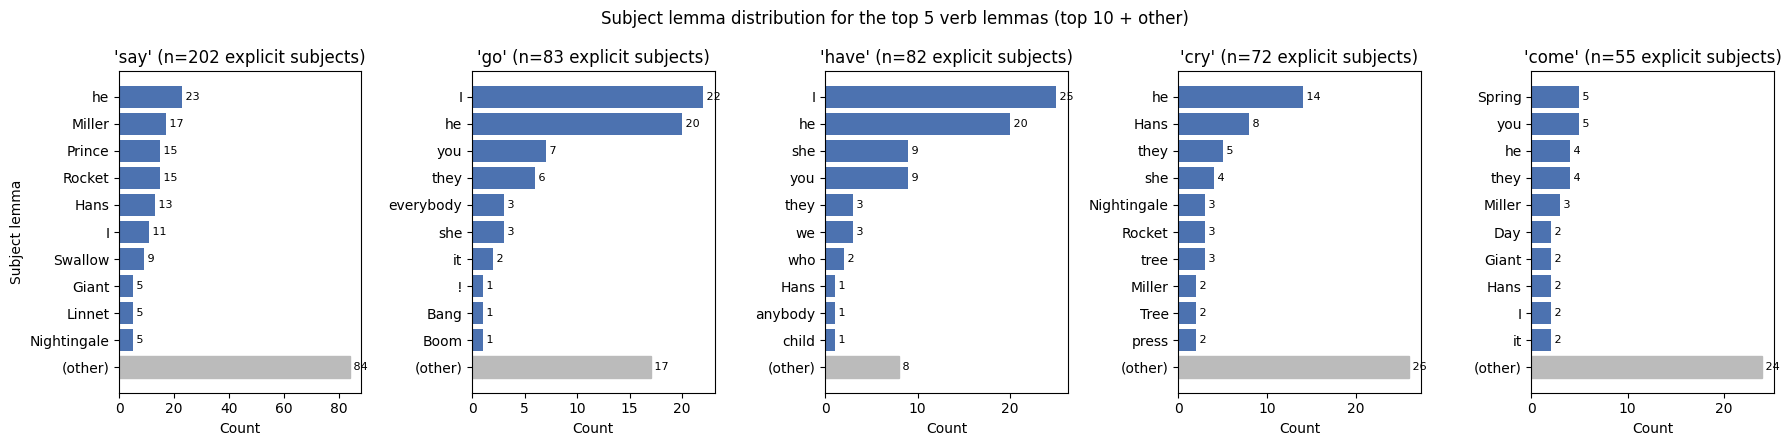

In [ ]:
# 4.1.2 plot: top subject lemmas for each of the top 5 verbs
TOP_K = 10
fig, axes = plt.subplots(1, len(top5_verbs), figsize=(18, 4.5), sharex=False)

for ax, verb in zip(axes, top5_verbs):
    dist = sorted(subject_dist[verb].items(), key=lambda kv: (-kv[1], kv[0]))
    total = sum(c for _, c in dist)
    top = dist[:TOP_K]
    other = total - sum(c for _, c in top)
    labels = [s for s, _ in top] + (["(other)"] if other else [])
    counts = [c for _, c in top] + ([other] if other else [])

    ax.barh(labels[::-1], counts[::-1], color="#4C72B0")
    if other:  # grey out the "other" bucket
        ax.patches[0].set_color("#BBBBBB")
    ax.set_title(f"'{verb}' (n={total} explicit subjects)")
    ax.set_xlabel("Count")
    for y, c in enumerate(counts[::-1]):
        ax.text(c, y, f" {c}", va="center", fontsize=8)

axes[0].set_ylabel("Subject lemma")
fig.suptitle(f"Subject lemma distribution for the top 5 verb lemmas (top {TOP_K} + other)")
fig.tight_layout()
fig.savefig("results/verb_subject_dist.png", dpi=150)
plt.show()

**4.1.3 Answer**: Yes. Speech verbs like say and cry take almost only animate subjects, either pronouns (he, I) or characters. Many of those characters aren't human (Rocket, Swallow, Candle): a speech verb makes whatever fills the subject slot act like a person. Come is the interesting contrast. About 40% of its subjects (22 of 55) aren't living things: seasons and weather (Spring, winter, frost, snow) or sensations (sound, perfume). Come describes things arriving or happening, so it accepts inanimate subjects, while say needs a speaker.

## Part 5: Bonus: Language puzzles (10 points)

The following sentences are from a perturbed version of a real language, presented alongside their translations into English. Your task is to match each phrase in **Language Y** with its correct **English** translation.

|   | Language Y                     |   | English                  |
|---|--------------------------------|---|--------------------------|
| A | he shege ptauege yaijeech      | 1 | the cousin's teacher     |
| B | heau shege yaijeege stauyau    | 2 | the nurses' cousin       |
| C | heau shai ugheedai hyoogeshyau | 3 | the architects' teachers |
| D | heau shege eegeege oogheedyau  | 4 | the schools' architect   |
| E | he shai stauai eegeech         | 5 | the teachers' schools    |
| F | he shai yausai stauich         | 6 | the tools' managers      |
| G | he shege hyoogesheege yauseech | 7 | the manager's nurses     |
| H | heau shege staueege ptauyau    | 8 | the professor's tool     |

**Your Answer:**

★ Provide your final matching (e.g., A-1, B-2, C-3, ...). Briefly explain the logic you used to decipher the language, including how possession (e.g., 's) and plurals are marked.

**Answer:** A-4, B-3, C-7, D-6, E-8, F-1, G-2, H-5

**Structure:** Each phrase is `[article] [possessive particle] [possessor] [possessed]`, so the possessor comes first.

**Plurals:** Number is marked twice for each noun, once on a function word and once as a suffix.
- *Possessed noun:* the article (`he` = singular, `heau` = plural) and the suffix on the last word (`-eech`/`-ich` = singular, `-yau` = plural).
- *Possessor noun:* the possessive particle (`shai` = singular, `shege` = plural) and the suffix on the third word (`-ai` = singular, `-(e)ege` = plural).

**Possession ('s):** Possession is shown by the particle `shai`/`shege` together with word order (possessor before possessed). The particle agrees in number with the possessor.

**Method:**
1. Counting splits: `he`/`heau` split 4/4, matching the English possessed nouns (4 sg, 4 pl). `shai`/`shege` split 3/5, matching the English possessors (3 sg, 5 pl).
2. I pulled out the noun stems and noted which stems occur together in a phrase. `stau` appears 4 times, so it must cover both *teacher* (3) and *professor* (1).
3. Phrases A, B and H only share nouns with each other, just like English 3, 4 and 5 (architect, school, teacher). The other five phrases link into a chain through shared nouns, just like English 1, 2, 6, 7 and 8. Using the sg/pl markers gives only one consistent assignment. G ("the nurses' cousin") and C ("the manager's nurses") share `hyoogesh` = *nurse*, which shows the possessor comes first.

**Word matching:** stau = teacher/professor, ptau = school, yaij = architect, yaus = cousin, hyoogesh = nurse, ugheed/oogheed = manager (vowels perturbed), eeg = tool.

## Academic integrity

You can discuss high-level solutions with classmates, but your submitted work should be your own. Don't copy from or share code with one another. Provide attribution for any sources of assistance you used in the assignment. If you use generative AI tools to aid in any parts of this assignment, describe how you used them and what worked (or didn't work) when using them.

**Answer**: I implemented the core logic, coding formulas, and writeups by myself. I used Claude code to double check my implementation correctness and I used it to generate code for matplotlib graphs.

## Prepare your submission

You may submit partial work. Save the notebook, then run the cell below on Colab.
Leave `include_report = True` to upload your report (a partial report is fine), or
set it to `False` to skip the report. Canceling the upload also skips the report.
The helper captures the notebook you have open and packages all available results.
It warns about missing files, invalid outputs, and Python syntax errors, but still
creates and downloads `submission.zip`. Submit that ZIP to Gradescope.

The notebook itself must be a readable `.ipynb` file. Completed parts are graded
independently where possible; a syntax error causes its code cell to be skipped.
Functions that depend on missing or broken code can still fail. Rerun affected
cells after edits so saved results match your code.

For local Jupyter, save the notebook, place any `report.pdf` beside it, and run
`python make_submission.py` from the homework directory. Missing reports and
results are allowed. Use `--no-report` to exclude an existing report.


In [2]:
# Run after setup, even if you have only completed part of the homework.
include_report = True  # Set False to submit without uploading a report.
if "google.colab" in sys.modules:
    from make_submission import from_colab
    from_colab(include_report=include_report)
else:
    print("Save hw2.ipynb, then run: python make_submission.py")


Select your report PDF, or cancel the upload to submit without a report.


Saving cs283-hw2.pdf to cs283-hw2.pdf
Packaging partial work. Missing or invalid answers may lose the corresponding credit:
  - Notebook cell 74: invalid syntax; this cell cannot be graded.
Created /content/drive/MyDrive/cs183-hw2/submission.zip (12 files). Format checks do not grade correctness.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>